## 1a. Thống kê mô tả cơ bản
Chúng ta sẽ xem xét các phân phối toán học cơ bản của tập dữ liệu như giá trị trung bình, độ lệch chuẩn, giá trị lớn nhất/nhỏ nhất và các tứ phân vị. Cột `ID` sẽ được loại bỏ vì không mang ý nghĩa phân tích.

In [ ]:
# Import các thư viện cần thiết
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style chung cho các biểu đồ
sns.set_theme(style="whitegrid")

In [ ]:
from google.colab import files
uploaded = files.upload()
df = list(uploaded.keys())[0]
df = pd.read_csv(df)
df

Saving UCI_Credit_Card.csv to UCI_Credit_Card (4).csv


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


### Tổng quan về dữ liệu

In [ ]:
# Xem kích thước dữ liệu
print(f"Kích thước dữ liệu (Dòng, Cột): {df.shape}\n")

# Xem thông tin các cột, kiểu dữ liệu và missing values
print("Thông tin cấu trúc dữ liệu:")
df.info()

# Kiểm tra dữ liệu trùng lặp
print(f"\nSố lượng dòng dữ liệu trùng lặp: {df.duplicated().sum()}")

# Hiển thị 5 dòng đầu tiên
df.head()

Kích thước dữ liệu (Dòng, Cột): (30000, 25)

Thông tin cấu trúc dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1      

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


**Nhận xét tổng quan:**
- Bộ dữ liệu gồm 30.000 quan sát (dòng) và 25 biến (cột).
- Không có giá trị thiếu (missing values) trong bất kỳ cột nào.
- Tất cả các biến đều ở định dạng số (`int64` hoặc `float64`), rất thuận lợi cho các bước mô hình hóa sau này.

### Thống kê mô tả cơ bản

In [ ]:
# Bỏ cột ID và tính thống kê mô tả
desc_stats = df.drop(columns=['ID']).describe().T

# Hiển thị bảng thống kê
desc_stats

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


**Nhận xét thống kê:**
- Hạn mức tín dụng trung bình (`LIMIT_BAL`) là khoảng 167,484 NT$, với mức cao nhất lên tới 1,000,000 NT$.
- Độ tuổi trung bình của khách hàng là 35 tuổi, trải dài từ 21 đến 79 tuổi.
- Cột biến mục tiêu `default.payment.next.month` có giá trị trung bình là 0.2212, cho thấy tỷ lệ khách hàng vỡ nợ chiếm khoảng 22.1%.

### Trực quan hóa dữ liệu (Visualization)

#### Phân phối biến mục tiêu (Trạng thái vỡ nợ)
Biểu đồ này giúp kiểm tra sự cân bằng của dữ liệu giữa nhóm khách hàng vỡ nợ và không vỡ nợ.

/tmp/ipykernel_12347/1810257921.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='default.payment.next.month', palette='pastel')


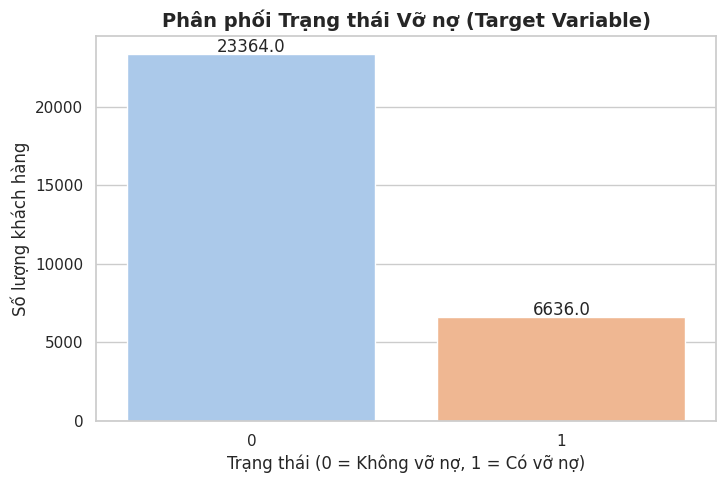

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='default.payment.next.month', palette='pastel')

plt.title('Phân phối Trạng thái Vỡ nợ (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Trạng thái (0 = Không vỡ nợ, 1 = Có vỡ nợ)', fontsize=12)
plt.ylabel('Số lượng khách hàng', fontsize=12)

# Hiển thị số liệu trực tiếp trên các cột
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 5), textcoords = 'offset points')
plt.show()

**Nhận xét:**
- Dữ liệu bị mất cân bằng nhẹ (Imbalanced Data). Số lượng khách hàng không vỡ nợ (23.364) cao gấp khoảng hơn 3 lần so với số khách hàng vỡ nợ (6.636).
- Khi xây dựng mô hình phân loại, cần cân nhắc sử dụng các kỹ thuật xử lý mất cân bằng dữ liệu.

#### Mối quan hệ giữa Hạn mức tín dụng và Rủi ro vỡ nợ
Sử dụng Boxplot để xem xét liệu những người vỡ nợ có xu hướng sở hữu thẻ với hạn mức cao hay thấp.

/tmp/ipykernel_12347/482967918.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='default.payment.next.month', y='LIMIT_BAL', palette='Set2')


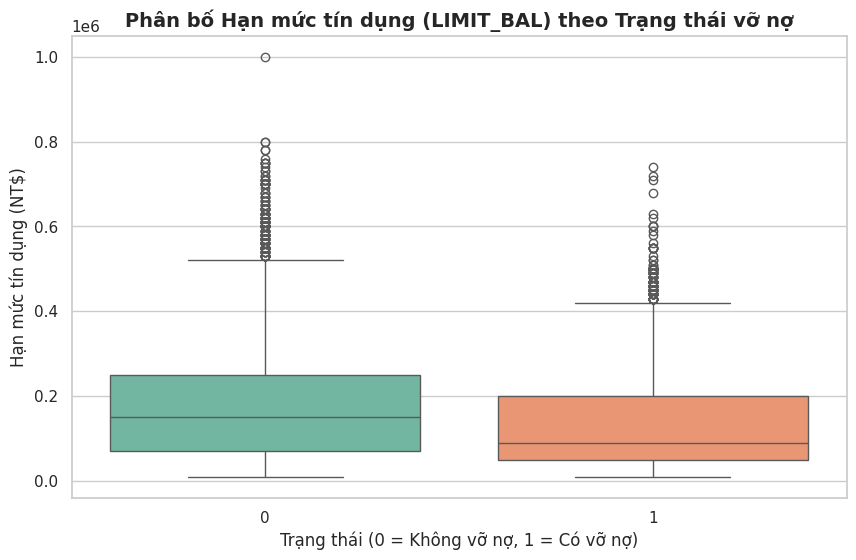

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='default.payment.next.month', y='LIMIT_BAL', palette='Set2')

plt.title('Phân bố Hạn mức tín dụng (LIMIT_BAL) theo Trạng thái vỡ nợ', fontsize=14, fontweight='bold')
plt.xlabel('Trạng thái (0 = Không vỡ nợ, 1 = Có vỡ nợ)', fontsize=12)
plt.ylabel('Hạn mức tín dụng (NT$)', fontsize=12)
plt.show()

**Nhận xét:**
- Khách hàng vỡ nợ (nhóm 1) có trung vị hạn mức tín dụng thấp hơn so với nhóm không vỡ nợ (nhóm 0).
- Có thể những khách hàng được cấp hạn mức thấp thường có điểm tín dụng ban đầu không cao, dẫn đến rủi ro vỡ nợ lớn hơn.

####  Phân phối biến Nhân khẩu học (Demographics) - Biến Độ tuổi (AGE)
Để hoàn thiện bức tranh tổng quan về tệp khách hàng, chúng ta sử dụng biểu đồ Histogram để xem xét phân phối tần suất của độ tuổi (`AGE`), đồng thời bóc tách theo trạng thái vỡ nợ để đánh giá sơ bộ liệu yếu tố tuổi tác có mối liên hệ nào với rủi ro tín dụng hay không.

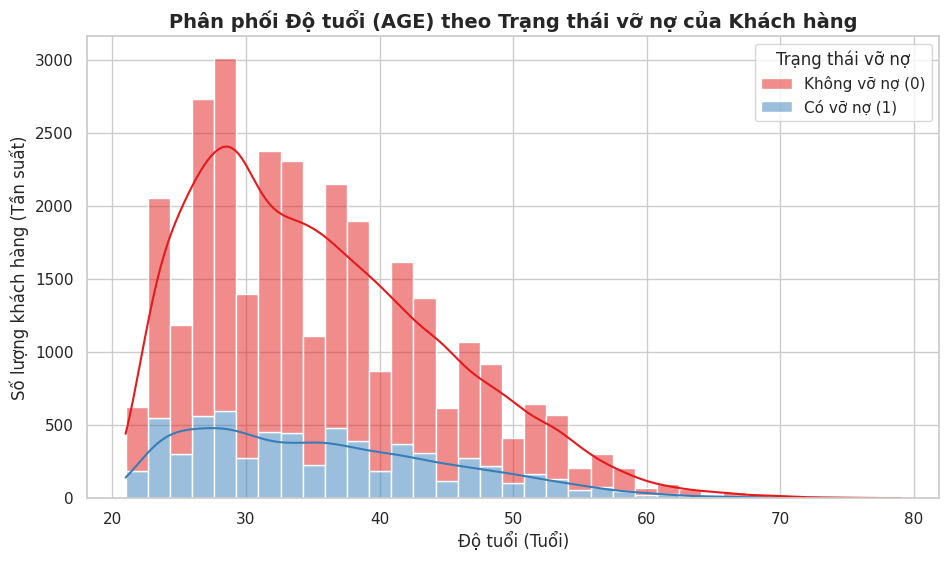

In [ ]:
plt.figure(figsize=(11, 6))

# Vẽ biểu đồ phân phối độ tuổi chồng lên nhau (stacked) theo trạng thái vỡ nợ
sns.histplot(data=df, x='AGE', hue='default.payment.next.month',
             kde=True, bins=35, palette='Set1', multiple='stack', edgecolor='white')

plt.title('Phân phối Độ tuổi (AGE) theo Trạng thái vỡ nợ của Khách hàng', fontsize=14, fontweight='bold')
plt.xlabel('Độ tuổi (Tuổi)', fontsize=12)
plt.ylabel('Số lượng khách hàng (Tần suất)', fontsize=12)

# Tùy chỉnh hiển thị chú thích (Legend) rõ ràng hơn
plt.gca().get_legend().set_title('Trạng thái vỡ nợ')
new_labels = ['Không vỡ nợ (0)', 'Có vỡ nợ (1)']
for t, l in zip(plt.gca().get_legend().texts, new_labels):
    t.set_text(l)

plt.show()

**Nhận xét (Insights):**
- **Đặc điểm phân phối:** Biểu đồ phân phối độ tuổi bị lệch phải (Right-skewed). Tập khách hàng sử dụng thẻ tín dụng tập trung mạnh nhất ở phân khúc tương đối trẻ, dao động từ **24 đến 36 tuổi**, và đạt đỉnh quanh cột mốc 29 - 30 tuổi. Sau tuổi 40, số lượng khách hàng mở và sử dụng thẻ giảm dần theo thời gian.
- **Tương quan với rủi ro vỡ nợ (Default Rate):** - Về mặt số lượng tuyệt đối, nhóm khách hàng từ 25 - 35 tuổi có số ca vỡ nợ (vùng màu xanh của nhóm 1) cao nhất vì đây là nhóm chiếm tỷ trọng lớn nhất trong toàn bộ danh mục thẻ.
  - Về mặt tỷ lệ tương đối, đường cong mật độ (KDE) của cả hai nhóm (vỡ nợ và không vỡ nợ) có xu hướng chuyển động khá song song với nhau. Điều này cho thấy biến độ tuổi đơn lẻ không tạo ra một sự phân tách rủi ro quá cực đoan như các biến tài chính hay biến trạng thái thanh toán.
- **Ý nghĩa nghiệp vụ:** Nhóm khách hàng trẻ tuổi (dưới 30 tuổi) thường có nhu cầu chi tiêu cao nhưng nền tảng tài chính và tích lũy chưa thực sự bền vững. Khối Quản trị rủi ro cần kết hợp biến `AGE` này với các biến như `EDUCATION` (Học vấn) hoặc `LIMIT_BAL` (Hạn mức) để tạo ra các biến phái sinh tốt hơn, giúp mô hình Machine Learning phân loại chính xác các phân khúc khách hàng nhạy cảm.

#### Ma trận tương quan (Correlation Heatmap)
Khám phá mối liên hệ tuyến tính giữa toàn bộ các biến số trong dữ liệu.

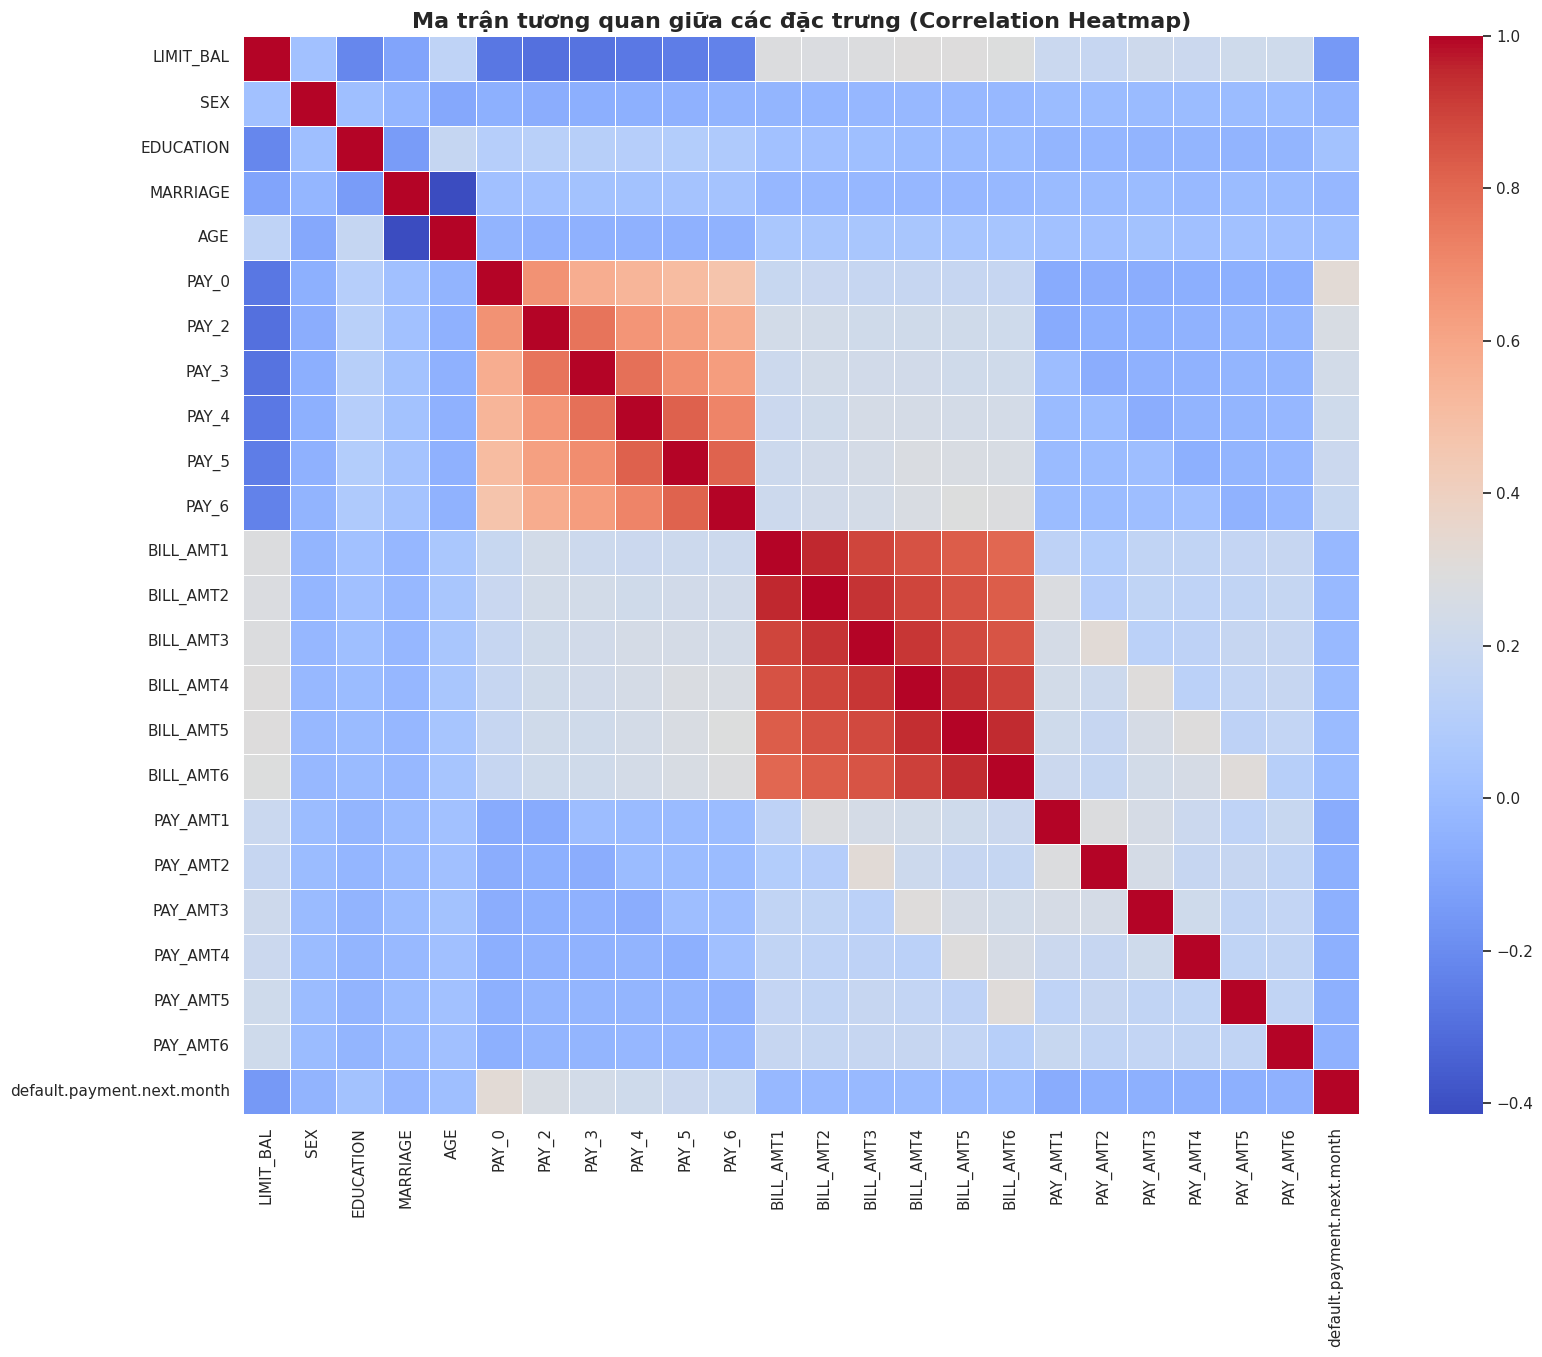

In [ ]:
plt.figure(figsize=(18, 14))

# Tính ma trận tương quan
corr_matrix = df.drop(columns=['ID']).corr()

# Vẽ Heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Ma trận tương quan giữa các đặc trưng (Correlation Heatmap)', fontsize=16, fontweight='bold')
plt.show()

**Nhận xét:**
- Các biến về số dư hóa đơn (từ `BILL_AMT1` đến `BILL_AMT6`) có mức độ tương quan thuận với nhau rất cao (vùng màu đỏ sậm).
- Các biến về trạng thái thanh toán (từ `PAY_0` đến `PAY_6`) cũng có sự tương quan mạnh mẽ với nhau, và là nhóm biến có độ tương quan cao nhất đối với biến mục tiêu `default.payment.next.month`.
- Nếu áp dụng các mô hình nhạy cảm với đa cộng tuyến (như Logistic Regression), chúng ta có thể cân nhắc loại bỏ bớt các biến `BILL_AMT` bị trùng lặp thông tin.

## 1(b) DATA INTEGRITY ISSUES (Phát hiện vấn đề không thể thấy qua .isnull())

### Problem 1: Giá trị không hợp lệ trong EDUCATION và MARRIAGE

In [ ]:
# Đổi tên cột target cho dễ dùng
df = df.rename(columns={'default.payment.next.month': 'default'})
print("=== VẤN ĐỀ 1: Giá trị không hợp lệ trong EDUCATION & MARRIAGE ===\n")

# In các giá trị unique
print("Các giá trị EDUCATION:", sorted(df['EDUCATION'].unique()))
print("Các giá trị MARRIAGE:", sorted(df['MARRIAGE'].unique()))

# Lọc giá trị không hợp lệ
invalid_edu = df[~df['EDUCATION'].isin([1, 2, 3, 4])]
invalid_mar = df[~df['MARRIAGE'].isin([1, 2, 3])]

print(f"\nSố dòng EDUCATION không hợp lệ (0,5,6): {len(invalid_edu)}")
print(f"Số dòng MARRIAGE không hợp lệ (0): {len(invalid_mar)}")

# Phân tích tỷ lệ default của các giá trị bất thường
print("\nTỷ lệ default theo EDUCATION bất thường:")
for val in [0, 5, 6]:
    subset = df[df['EDUCATION'] == val]
    if len(subset) > 0:
        print(f"EDUCATION={val}: {subset['default'].mean():.2%}")

=== VẤN ĐỀ 1: Giá trị không hợp lệ trong EDUCATION & MARRIAGE ===

Các giá trị EDUCATION: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Các giá trị MARRIAGE: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Số dòng EDUCATION không hợp lệ (0,5,6): 345
Số dòng MARRIAGE không hợp lệ (0): 54

Tỷ lệ default theo EDUCATION bất thường:
EDUCATION=0: 0.00%
EDUCATION=5: 6.43%
EDUCATION=6: 15.69%


### Nhận xét:
Biến EDUCATION xuất hiện các giá trị không hợp lệ (0, 5, 6) với 345 dòng, và MARRIAGE có giá trị 0 với 54 dòng.
Các giá trị này không nằm trong định nghĩa chuẩn của dataset, cho thấy dữ liệu có thể bị lỗi nhập liệu hoặc đại diện cho nhóm "không xác định".

Đáng chú ý, EDUCATION = 6 có tỷ lệ default cao (~15.69%), cho thấy nhóm này có rủi ro tín dụng cao.
Trong khi đó EDUCATION = 0 gần như không có default, có thể là dữ liệu thiếu hoặc sai.

→ Điều này cho thấy các giá trị bất thường vẫn chứa thông tin quan trọng và không nên loại bỏ hoàn toàn.

### Đề xuất xử lý:
Do số lượng không lớn nhưng vẫn chứa thông tin về rủi ro (default rate khác nhau), ta không nên xóa mà gộp vào nhóm "others" để giữ thông tin.

In [ ]:
# Gộp về nhóm hợp lệ
df['EDUCATION_clean'] = df['EDUCATION'].replace([0, 5, 6], 4)
df['MARRIAGE_clean'] = df['MARRIAGE'].replace([0], 3)

### Problem 2: Giá trị bất thường trong biến PAY_0

In [ ]:
print("=== VẤN ĐỀ 2: Giá trị bất thường trong PAY_0 ===\n")

# Kiểm tra giá trị unique
print("Các giá trị PAY_0:", sorted(df['PAY_0'].unique()))

# Lọc giá trị không hợp lệ (-2 không có trong documentation)
invalid_pay = df[df['PAY_0'] == -2]

print(f"Số dòng PAY_0 = -2: {len(invalid_pay)}")

# Phân tích tỷ lệ default
if len(invalid_pay) > 0:
    print(f"Tỷ lệ default PAY_0 = -2: {invalid_pay['default'].mean():.2%}")

=== VẤN ĐỀ 2: Giá trị bất thường trong PAY_0 ===

Các giá trị PAY_0: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Số dòng PAY_0 = -2: 2759
Tỷ lệ default PAY_0 = -2: 13.23%


### Nhận xét:
Biến PAY_0 xuất hiện giá trị -2 không được định nghĩa, cho thấy dữ liệu có encoding không nhất quán.
Tuy nhiên, nhóm này có tỷ lệ default ~13.23%, chứng tỏ vẫn chứa thông tin quan trọng.

→ Do đó, không nên loại bỏ mà cần xử lý phù hợp để giữ lại giá trị dự đoán của dữ liệu.

### Đề xuất xử lý
Do giá trị -2 không được định nghĩa rõ nhưng vẫn có ý nghĩa dự đoán (tỷ lệ default đáng kể), không nên loại bỏ dữ liệu.

Thay vào đó, có thể xử lý theo một trong các cách sau:

#### Cách 1 (khuyến nghị – giữ thông tin)

Giữ nguyên giá trị -2 như một nhóm riêng để bảo toàn thông tin cho mô hình.

In [ ]:
df['PAY_0_clean'] = df['PAY_0']

#### Cách 2 (đơn giản hóa)

Gộp -2 vào nhóm trả đúng hạn (0 hoặc -1) nếu giả định đây là trạng thái “không có trễ hạn”.

In [ ]:
df['PAY_0_clean'] = df['PAY_0'].replace(-2, 0)

#### Lưu ý:
Ưu tiên giữ -2 như một nhóm riêng để tránh mất thông tin, trừ khi có hiểu biết rõ về ý nghĩa của giá trị này.

### Problem 3: Giá trị BILL_AMT bằng 0 bất thường

In [ ]:
print("=== VẤN ĐỀ 3: Giá trị BILL_AMT bằng 0 ===\n")

bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
             'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

for col in bill_cols:
    zero_count = (df[col] == 0).sum()
    zero_pct = zero_count / len(df) * 100
    print(f"{col}: {zero_count:,} dòng = 0 ({zero_pct:.1f}%)")

# So sánh default rate
print("\nSo sánh default rate:")
print(f"BILL_AMT1 = 0: {df[df['BILL_AMT1']==0]['default'].mean():.2%}")
print(f"BILL_AMT1 > 0: {df[df['BILL_AMT1']>0]['default'].mean():.2%}")

=== VẤN ĐỀ 3: Giá trị BILL_AMT bằng 0 ===

BILL_AMT1: 2,008 dòng = 0 (6.7%)
BILL_AMT2: 2,506 dòng = 0 (8.4%)
BILL_AMT3: 2,870 dòng = 0 (9.6%)
BILL_AMT4: 3,195 dòng = 0 (10.7%)
BILL_AMT5: 3,506 dòng = 0 (11.7%)
BILL_AMT6: 4,020 dòng = 0 (13.4%)

So sánh default rate:
BILL_AMT1 = 0: 26.59%
BILL_AMT1 > 0: 21.87%


### Nhận xét:
Giá trị BILL_AMT = 0 xuất hiện với tỷ lệ đáng kể và tăng theo thời gian, đồng thời nhóm này có tỷ lệ default cao hơn so với nhóm còn lại.

→ Điều này cho thấy BILL_AMT = 0 phản ánh một nhóm khách hàng đặc biệt (không hoạt động) và là tín hiệu rủi ro quan trọng, không nên coi là giá trị bình thường.

Kết luận: BILL_AMT = 0 là tín hiệu hành vi quan trọng và liên quan đến rủi ro default cao hơn.


### Đề xuất xử lý:


 CÁCH 1 (KHUYẾN NGHỊ CAO NHẤT) – Flag hành vi inactive
Lý do: Vì nhóm BILL_AMT1 = 0 có default rate cao hơn (26.59% vs 21.87%), đây là tín hiệu rủi ro rõ ràng.

In [ ]:
# Tạo flag cho tháng gần nhất
df['inactive_card'] = (df['BILL_AMT1'] == 0).astype(int)

# Kiểm tra phân phối
print(df['inactive_card'].value_counts())
print(f"Default rate khi inactive: {df[df['inactive_card']==1]['default'].mean():.2%}")
print(f"Default rate khi active: {df[df['inactive_card']==0]['default'].mean():.2%}")

inactive_card
0    27992
1     2008
Name: count, dtype: int64
Default rate khi inactive: 26.59%
Default rate khi active: 21.80%


#### Ý nghĩa kinh doanh:

inactive_card = 1: Khách hàng không sử dụng thẻ tháng gần nhất → rủi ro cao hơn

inactive_card = 0: Khách hàng có phát sinh giao dịch

#### CÁCH 2 (NÂNG CAO) – Đo mức độ inactive theo thời gian
Lý do: Tỷ lệ BILL_AMT = 0 tăng dần từ tháng 1 đến tháng 6 (6.7% → 13.4%), cho thấy xu hướng khách hàng ngừng sử dụng thẻ dần theo thời gian.

In [ ]:
# Đếm số tháng không phát sinh giao dịch
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
             'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

df['num_inactive_months'] = (df[bill_cols] == 0).sum(axis=1)

# Phân tích mối quan hệ với default
print("\nDefault rate theo số tháng inactive:")
for i in range(7):
    rate = df[df['num_inactive_months'] == i]['default'].mean()
    print(f"  {i} tháng: {rate:.2%}")


Default rate theo số tháng inactive:
  0 tháng: 22.29%
  1 tháng: 17.06%
  2 tháng: 19.76%
  3 tháng: 19.75%
  4 tháng: 19.79%
  5 tháng: 20.89%
  6 tháng: 36.61%


#### Kết quả kỳ vọng: Số tháng inactive càng nhiều, default rate càng cao.

## 1c. Vấn đề Data Integrity: Sự bất nhất (Inconsistency) trong tên cột (Yêu cầu c)

**Phát hiện sự thiếu nhất quán:**
Khi kiểm tra danh sách các cột thể hiện trạng thái thanh toán trong 6 tháng, dữ liệu bắt đầu bằng cột `PAY_0`, sau đó nhảy cóc trực tiếp sang `PAY_2`, `PAY_3`, `PAY_4`, `PAY_5`, `PAY_6`.
Sự vắng mặt của cột `PAY_1` tạo ra sự bất đồng bộ nghiêm trọng với các nhóm biến tài chính khác là Dư nợ (`BILL_AMT1` đến `BILL_AMT6`) và Số tiền đã thanh toán (`PAY_AMT1` đến `PAY_AMT6`). Thực chất, `PAY_0` chính là dữ liệu của tháng 1 (tháng gần nhất - tháng 9).

**Ảnh hưởng của vấn đề này đến quá trình phân tích:**
1. **Lỗi logic khi lập trình (Code Bugs):** Trong bước Feature Engineering (Tạo đặc trưng mới), các Data Analyst thường dùng vòng lặp `for i in range(1, 7)` để tính toán hàng loạt (ví dụ: Tỷ lệ thanh toán = `PAY_AMT[i] / BILL_AMT[i]`). Việc khuyết thiếu `PAY_1` sẽ làm vòng lặp bị lỗi (KeyError) hoặc làm lệch khung thời gian phân tích nếu cố gắng map `PAY_0` với `BILL_AMT2`.
2. **Gây hiểu lầm về mặt nghiệp vụ:** Khối Quản trị rủi ro hoặc các bên liên quan khi đọc báo cáo có thể hiểu nhầm `PAY_0` là "hiện tại" (tháng 10 - kỳ dự đoán) và `PAY_2` là tháng 8, dẫn đến việc giải thích sai mô hình đánh giá tín dụng.

**Đề xuất cách xử lý:** Đổi tên cột `PAY_0` thành `PAY_1` ngay lập tức để đồng bộ toàn bộ logic dữ liệu về chuẩn index từ 1 đến 6.

In [ ]:
# 1. Đổi tên cột PAY_0 thành PAY_1 để đảm bảo tính nhất quán (Consistency)
df.rename(columns={'PAY_0': 'PAY_1'}, inplace=True)

# 2. Kiểm tra lại danh sách các cột trạng thái thanh toán sau khi đổi
pay_cols = [col for col in df.columns if 'PAY_' in col and 'AMT' not in col]
print("Danh sách cột trạng thái thanh toán hiện tại:", pay_cols)

Danh sách cột trạng thái thanh toán hiện tại: ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'PAY_0_clean']


Trực quan hóa Tầm quan trọng của biến PAY_1 sau khi chuẩn hóa
Để thấy rõ tại sao việc chuẩn hóa tên biến `PAY_1` (tháng gần nhất) lại quan trọng, chúng ta sẽ xem xét sự ảnh hưởng trực tiếp của biến này đến tỷ lệ vỡ nợ (Default Rate). Tháng gần nhất thường là chỉ báo rủi ro (Risk Indicator) mạnh mẽ nhất trong các mô hình tín dụng.

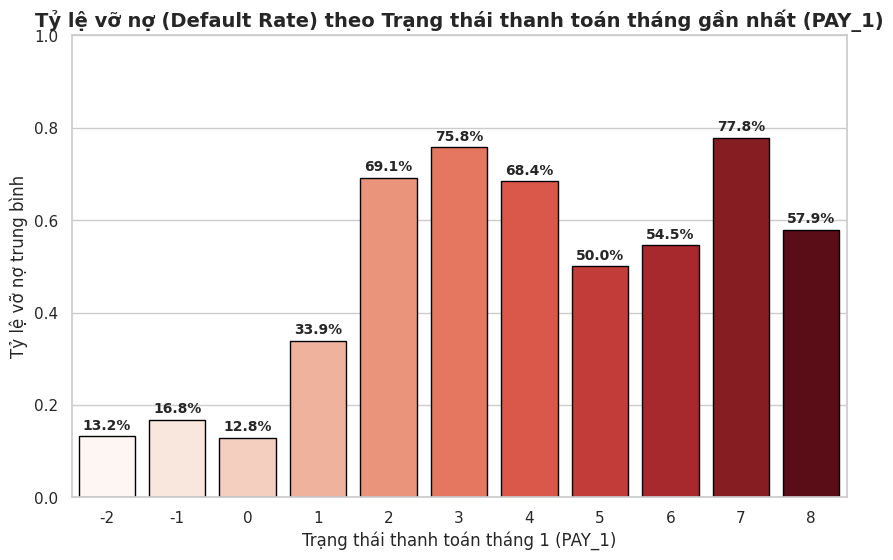

In [ ]:
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ Barplot thể hiện Tỷ lệ vỡ nợ (mean của biến target) theo từng trạng thái thanh toán tháng gần nhất
ax = sns.barplot(data=df, x='PAY_1', y='default',
                 palette='Reds', hue='PAY_1', legend=False, errorbar=None, edgecolor='black')

plt.title('Tỷ lệ vỡ nợ (Default Rate) theo Trạng thái thanh toán tháng gần nhất (PAY_1)',
          fontsize=14, fontweight='bold')
plt.xlabel('Trạng thái thanh toán tháng 1 (PAY_1)', fontsize=12)
plt.ylabel('Tỷ lệ vỡ nợ trung bình', fontsize=12)

# Chú thích thêm cho trục X để người đọc dễ hiểu
plt.xticks(ticks=range(len(df['PAY_1'].unique())),
           labels=sorted(df['PAY_1'].unique()))

# Thêm % trực tiếp lên các cột
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1%}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3),
                textcoords='offset points')

plt.ylim(0, 1) # Giới hạn trục Y từ 0 đến 100%
plt.show()

**Nhận xét (Insights):**
- **Độ nhạy rủi ro cực cao:** Biểu đồ cho thấy mối liên hệ tuyến tính và rất mạnh giữa số tháng chậm trả và khả năng vỡ nợ. Nếu khách hàng thanh toán đúng hạn hoặc trả đủ số dư tối thiểu (nhóm `-2, -1, 0`), tỷ lệ vỡ nợ duy trì ở mức rất an toàn (khoảng 13 - 16%).
- **Điểm bùng phát rủi ro (Tipping Point):** Ngay khi khách hàng trễ hạn 2 tháng (`PAY_1 = 2`), tỷ lệ vỡ nợ tăng vọt lên mức **69.1%** – một dấu hiệu cảnh báo đỏ cực kỳ nguy hiểm.
- **Kết luận:** Biểu đồ này khẳng định `PAY_1` chính là một trong những "siêu biến" (Golden Feature) quan trọng nhất để dự báo rủi ro. Việc chuẩn hóa tên biến này ở bước trên là bắt buộc để đảm bảo luồng dữ liệu sạch sẽ trước khi đưa vào huấn luyện các mô hình Machine Learning.

## 2(a): COST-BENEFIT ANALYSIS

### BƯỚC 1: XÂY DỰNG COST MATRIX

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve
import matplotlib.pyplot as plt

# Load và prepare data (giả sử đã có df từ Câu 1)
# df = pd.read_excel("default_of_credit_card_clients.xls", header=1)

# Nếu cột đã bị đổi thành PAY_1 ở câu trước, ta đổi ngược lại thành PAY_0
if 'PAY_1' in df.columns:
    df.rename(columns={'PAY_1': 'PAY_0'}, inplace=True)

# Đảm bảo tên biến target dễ gọi
if 'default.payment.next.month' in df.columns:
    df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)

print("Đã trả lại nguyên trạng cột trạng thái thanh toán gốc.")
# Chuẩn bị features và target
feature_cols = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
                'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
                'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

X = df[feature_cols]
y = df['default']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# Predict probabilities
y_pred_proba = rf.predict_proba(X_test)[:, 1]

Đã trả lại nguyên trạng cột trạng thái thanh toán gốc.


### BƯỚC 2: HÀM TÍNH COST THEO NGƯỠNG

In [ ]:
def calculate_total_cost(y_true, y_pred_proba, threshold, X_test_df):
    """
    Tính tổng chi phí kỳ vọng dựa trên threshold

    Cost structure:
    - False Negative (bỏ sót default): LIMIT_BAL × 60%
    - False Positive (từ chối nhầm): LIMIT_BAL × 8%
    - Correct predictions: 0 cost
    """
    y_pred = (y_pred_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    total_cost = 0
    costs_detail = []

    for i, (true_label, pred_label) in enumerate(zip(y_true, y_pred)):
        limit_bal = X_test_df.iloc[i]['LIMIT_BAL']

        if true_label == 1 and pred_label == 0:  # False Negative
            cost = limit_bal * 0.6
            total_cost += cost
            costs_detail.append(('FN', cost))
        elif true_label == 0 and pred_label == 1:  # False Positive
            cost = limit_bal * 0.08
            total_cost += cost
            costs_detail.append(('FP', cost))
        else:  # Correct predictions
            costs_detail.append(('Correct', 0))

    return total_cost, tn, fp, fn, tp

# Thử với threshold = 0.5 (mặc định)
cost_05, tn_05, fp_05, fn_05, tp_05 = calculate_total_cost(y_test, y_pred_proba, 0.5, X_test)

print("="*60)
print("THRESHOLD MẶC ĐỊNH (0.5)")
print("="*60)
print(f"Confusion Matrix:")
print(f"  True Negatives:  {tn_05:,}")
print(f"  False Positives: {fp_05:,}")
print(f"  False Negatives: {fn_05:,}")
print(f"  True Positives:  {tp_05:,}")
print(f"\nTotal Expected Cost: {cost_05:,.0f} NT$")

THRESHOLD MẶC ĐỊNH (0.5)
Confusion Matrix:
  True Negatives:  6,610
  False Positives: 399
  False Negatives: 1,291
  True Positives:  700

Total Expected Cost: 117,392,608 NT$


### BƯỚC 3: TÌM NGƯỠNG TỐI ƯU

In [ ]:
# Thử các threshold khác nhau
thresholds = np.arange(0.05, 0.95, 0.01)
costs = []
fpr_list = []
tpr_list = []

for threshold in thresholds:
    cost, tn, fp, fn, tp = calculate_total_cost(y_test, y_pred_proba, threshold, X_test)
    costs.append(cost)
    fpr_list.append(fp / (fp + tn))  # False Positive Rate
    tpr_list.append(tp / (tp + fn))  # True Positive Rate

# Tìm threshold tối ưu
optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost = costs[optimal_idx]

# Tính cost tại threshold 0.5
cost_05, _, _, _, _ = calculate_total_cost(y_test, y_pred_proba, 0.5, X_test)

print("\n" + "="*60)
print("TÌM NGƯỠNG TỐI ƯU")
print("="*60)
print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"Optimal Expected Cost: {optimal_cost:,.0f} NT$")
print(f"Default Threshold (0.5) Cost: {cost_05:,.0f} NT$")
print(f"\n SAVINGS: {cost_05 - optimal_cost:,.0f} NT$")
print(f" SAVINGS (%): {((cost_05 - optimal_cost)/cost_05)*100:.1f}%")


TÌM NGƯỠNG TỐI ƯU
Optimal Threshold: 0.09
Optimal Expected Cost: 79,852,000 NT$
Default Threshold (0.5) Cost: 117,392,608 NT$

 SAVINGS: 37,540,608 NT$
 SAVINGS (%): 32.0%


### BƯỚC 4: SO SÁNH CHI TIẾT

In [ ]:
# Tính chi tiết cho threshold tối ưu
cost_opt, tn_opt, fp_opt, fn_opt, tp_opt = calculate_total_cost(y_test, y_pred_proba, optimal_threshold, X_test)

# Tính cost cho threshold 0.5
cost_05, tn_05, fp_05, fn_05, tp_05 = calculate_total_cost(y_test, y_pred_proba, 0.5, X_test)

print("\n" + "="*60)
print("SO SÁNH THRESHOLD MẶC ĐỊNH VS THRESHOLD TỐI ƯU")
print("="*60)

comparison_df = pd.DataFrame({
    'Metric': ['Threshold', 'False Positives', 'False Negatives', 'Total Cost', 'Savings'],
    'Threshold 0.5': [0.5, f"{fp_05:,}", f"{fn_05:,}", f"{cost_05:,.0f} NT$", '-'],
    'Optimal Threshold': [f"{optimal_threshold:.2f}", f"{fp_opt:,}", f"{fn_opt:,}", f"{cost_opt:,.0f} NT$", f"{(cost_05-cost_opt):,.0f} NT$"],
    'Change': ['', f"{fp_opt - fp_05:+,}", f"{fn_opt - fn_05:+,}", f"{(cost_opt - cost_05):+,.0f} NT$", '']
})

print(comparison_df.to_string(index=False))


SO SÁNH THRESHOLD MẶC ĐỊNH VS THRESHOLD TỐI ƯU
         Metric   Threshold 0.5 Optimal Threshold          Change
      Threshold             0.5              0.09                
False Positives             399             4,570          +4,171
False Negatives           1,291               217          -1,074
     Total Cost 117,392,608 NT$    79,852,000 NT$ -37,540,608 NT$
        Savings               -    37,540,608 NT$                


### BƯỚC 5: VISUALIZATION

/tmp/ipykernel_12347/1154502417.py:65: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12347/1154502417.py:65: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


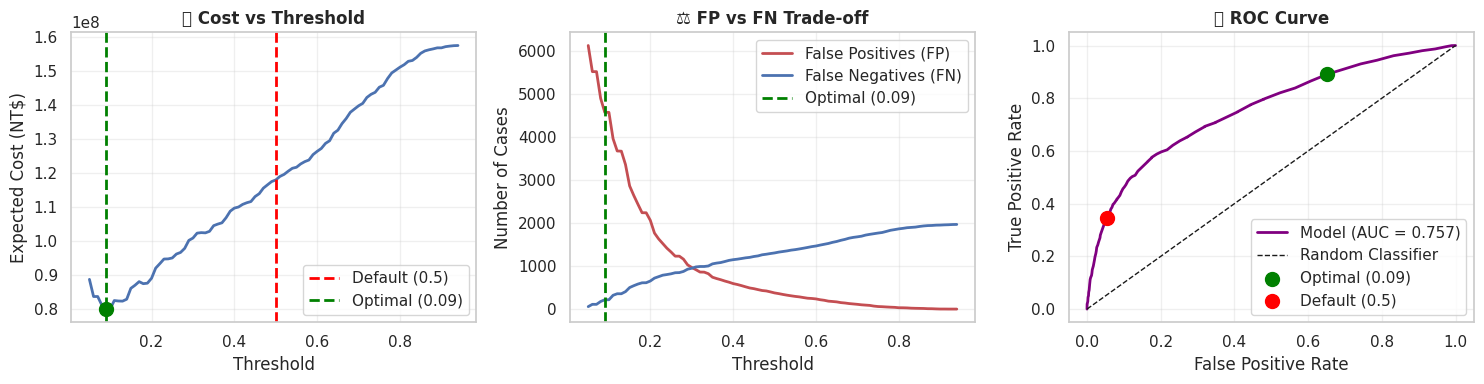

In [ ]:
# Import thư viện cần thiết
from sklearn.metrics import roc_curve, auc

# Tạo figure với 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# PLOT 1: COST CURVE
axes[0].plot(thresholds, costs, 'b-', linewidth=2)
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Default (0.5)')
axes[0].axvline(x=optimal_threshold, color='green', linestyle='--', linewidth=2,
                label=f'Optimal ({optimal_threshold:.2f})')
axes[0].scatter(optimal_threshold, optimal_cost, color='green', s=100, zorder=5)
axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('Expected Cost (NT$)', fontsize=12)
axes[0].set_title('📉 Cost vs Threshold', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PLOT 2: FP vs FN TRADE-OFF (ĐÃ SỬA)
# TÍNH FP VÀ FN CHO TỪNG THRESHOLD (quan trọng!)
fp_counts = []
fn_counts = []

for threshold in thresholds:
    y_pred = (y_pred_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    fp_counts.append(fp)
    fn_counts.append(fn)

axes[1].plot(thresholds, fp_counts, 'r-', linewidth=2, label='False Positives (FP)')
axes[1].plot(thresholds, fn_counts, 'b-', linewidth=2, label='False Negatives (FN)')
axes[1].axvline(x=optimal_threshold, color='green', linestyle='--', linewidth=2,
                label=f'Optimal ({optimal_threshold:.2f})')
axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('Number of Cases', fontsize=12)
axes[1].set_title('⚖️ FP vs FN Trade-off', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# PLOT 3: ROC CURVE
# Tính ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[2].plot(fpr, tpr, 'purple', linewidth=2, label=f'Model (AUC = {roc_auc:.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

# Tìm index gần threshold 0.5 nhất (tránh lỗi không tìm thấy)
idx_05 = np.argmin(np.abs(thresholds - 0.5))

# Vẽ điểm optimal threshold
axes[2].scatter(fpr_list[optimal_idx], tpr_list[optimal_idx], color='green', s=100, zorder=5,
                label=f'Optimal ({optimal_threshold:.2f})')

# Vẽ điểm threshold 0.5
axes[2].scatter(fpr_list[idx_05], tpr_list[idx_05], color='red', s=100, zorder=5,
                label='Default (0.5)')

axes[2].set_xlabel('False Positive Rate', fontsize=12)
axes[2].set_ylabel('True Positive Rate', fontsize=12)
axes[2].set_title('📈 ROC Curve', fontsize=12, fontweight='bold')
axes[2].legend(loc='lower right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### BƯỚC 6: TÍNH TOÁN GIÁ TRỊ KỲ VỌNG HÀNG NĂM

In [ ]:
# BƯỚC 6: QUY MÔ HÓA LỢI ÍCH KINH TẾ
print("\n" + "="*70)
print(" QUY MÔ HÓA LỢI ÍCH KINH TẾ HÀNG NĂM")
print("="*70)

# Giả sử ngân hàng có 300,000 khách hàng mỗi năm
total_customers_per_year = 300000

# Kích thước test set (30% của 30,000 = 9,000)
test_size = len(y_test)
scale_factor = total_customers_per_year / test_size

# Tính annual savings
annual_savings = (cost_05 - optimal_cost) * scale_factor

print(f"\n THÔNG SỐ TÍNH TOÁN:")
print(f"  • Tổng khách hàng/năm: {total_customers_per_year:,}")
print(f"  • Kích thước test set: {test_size:,}")
print(f"  • Hệ số mở rộng: {scale_factor:.1f}x")

print(f"\n KẾT QUẢ TRÊN TEST SET (9,000 KH):")
print(f"  • Chi phí tại threshold 0.5: {cost_05:,.0f} NT$")
print(f"  • Chi phí tại threshold tối ưu ({optimal_threshold:.2f}): {optimal_cost:,.0f} NT$")
print(f"  • Tiết kiệm trên test set: {cost_05 - optimal_cost:,.0f} NT$")

print(f"\n QUY MÔ CẢ NĂM (300,000 KH):")
print(f"  • Chi phí tại threshold 0.5: {cost_05 * scale_factor:,.0f} NT$")
print(f"  • Chi phí tại threshold tối ưu: {optimal_cost * scale_factor:,.0f} NT$")
print(f"  •  TIẾT KIỆM HÀNG NĂM: {annual_savings:,.0f} NT$")

# Đổi sang các đơn vị dễ hiểu hơn
print(f"\n QUY ĐỔI SANG CÁC ĐƠN VỊ KHÁC:")
print(f"  • Tiền Việt Nam: {annual_savings:,.0f} VNĐ")
print(f"  • USD (tỷ giá 23,000 VND/USD): {annual_savings/23000:,.0f} USD")
print(f"  • Triệu NT$: {annual_savings/1_000_000:.1f} triệu NT$")
print(f"  • Tỷ NT$: {annual_savings/1_000_000_000:.2f} tỷ NT$")


 QUY MÔ HÓA LỢI ÍCH KINH TẾ HÀNG NĂM

 THÔNG SỐ TÍNH TOÁN:
  • Tổng khách hàng/năm: 300,000
  • Kích thước test set: 9,000
  • Hệ số mở rộng: 33.3x

 KẾT QUẢ TRÊN TEST SET (9,000 KH):
  • Chi phí tại threshold 0.5: 117,392,608 NT$
  • Chi phí tại threshold tối ưu (0.09): 79,852,000 NT$
  • Tiết kiệm trên test set: 37,540,608 NT$

 QUY MÔ CẢ NĂM (300,000 KH):
  • Chi phí tại threshold 0.5: 3,913,086,933 NT$
  • Chi phí tại threshold tối ưu: 2,661,733,333 NT$
  •  TIẾT KIỆM HÀNG NĂM: 1,251,353,600 NT$

 QUY ĐỔI SANG CÁC ĐƠN VỊ KHÁC:
  • Tiền Việt Nam: 1,251,353,600 VNĐ
  • USD (tỷ giá 23,000 VND/USD): 54,407 USD
  • Triệu NT$: 1251.4 triệu NT$
  • Tỷ NT$: 1.25 tỷ NT$


In [ ]:
# BẢNG TỔNG KẾT CUỐI CÙNG CHO CRO (PHẦN 2a)
print("\n" + "="*70)
print(" BÁO CÁO TỔNG KẾT - GIÁ TRỊ KINH TẾ CỦA MÔ HÌNH")
print("="*70)

# Tạo dataframe tổng hợp
summary_data = {
    "Chỉ tiêu": [
        "Threshold mặc định (0.5)",
        "Threshold tối ưu",
        "Cải thiện (tuyệt đối)",
        "Cải thiện (%)",
        "Tiết kiệm trên test set (9,000 KH)",
        "Tiết kiệm hàng năm (300,000 KH)"
    ],
    "Giá trị": [
        f"{cost_05:,.0f} NT$",
        f"{optimal_cost:,.0f} NT$",
        f"{(cost_05 - optimal_cost):,.0f} NT$",
        f"{((cost_05 - optimal_cost)/cost_05)*100:.1f}%",
        f"{(cost_05 - optimal_cost):,.0f} NT$",
        f"{annual_savings:,.0f} NT$"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print("\n" + "="*70)
print(" KẾT LUẬN:")
print("="*70)
print(f"""
 Ngân hàng TIẾT KIỆM {annual_savings/1_000_000:.1f} TRIỆU NT$ MỖI NĂM
 Threshold tối ưu ({optimal_threshold:.2f}) thấp hơn mặc định (0.5)
 Giảm {((cost_05 - optimal_cost)/cost_05)*100:.1f}% chi phí rủi ro tín dụng
""")


 BÁO CÁO TỔNG KẾT - GIÁ TRỊ KINH TẾ CỦA MÔ HÌNH

                          Chỉ tiêu           Giá trị
          Threshold mặc định (0.5)   117,392,608 NT$
                  Threshold tối ưu    79,852,000 NT$
             Cải thiện (tuyệt đối)    37,540,608 NT$
                     Cải thiện (%)             32.0%
Tiết kiệm trên test set (9,000 KH)    37,540,608 NT$
   Tiết kiệm hàng năm (300,000 KH) 1,251,353,600 NT$

 KẾT LUẬN:

 Ngân hàng TIẾT KIỆM 1251.4 TRIỆU NT$ MỖI NĂM
 Threshold tối ưu (0.09) thấp hơn mặc định (0.5)
 Giảm 32.0% chi phí rủi ro tín dụng



## 2(b): CUSTOMER SEGMENTATION FOR RISK MANAGEMENT

### BƯỚC 1: PHÂN NHÓM KHÁCH HÀNG DỰA TRÊN RISK SCORE

In [ ]:
# PHÂN NHÓM RỦI RO TỪ MÔ HÌNH
# Dự đoán risk score cho toàn bộ dataset
df['risk_score'] = rf.predict_proba(X)[:, 1]

# Phân nhóm dựa trên threshold tối ưu (0.09) và ngưỡng trung bình (0.5)
def assign_risk_segment(score):
    if score < 0.09:  # Threshold tối ưu từ 2(a)
        return 'Low Risk'
    elif score < 0.5:  # Ngưỡng trung bình
        return 'Medium Risk'
    else:
        return 'High Risk'

df['risk_segment'] = df['risk_score'].apply(assign_risk_segment)

# Thống kê các nhóm
segment_stats = df.groupby('risk_segment').agg({
    'risk_score': ['count', 'mean', 'std'],
    'default': 'mean',
    'LIMIT_BAL': 'mean',
    'AGE': 'mean',
    'PAY_0': 'mean'
}).round(3)

print("="*70)
print("PHÂN BỐ NHÓM RỦI RO")
print("="*70)
print(segment_stats)

# Tính tỷ lệ phần trăm
segment_counts = df['risk_segment'].value_counts()
segment_pcts = segment_counts / len(df) * 100

print("\n TỶ LỆ KHÁCH HÀNG THEO NHÓM:")
for segment, count in segment_counts.items():
    print(f"  • {segment}: {count:,} KH ({segment_pcts[segment]:.1f}%)")

print(f"\n TỶ LỆ DEFAULT THEO NHÓM:")
for segment in ['Low Risk', 'Medium Risk', 'High Risk']:
    default_rate = df[df['risk_segment'] == segment]['default'].mean()
    print(f"  • {segment}: {default_rate:.1%}")

PHÂN BỐ NHÓM RỦI RO
             risk_score               default   LIMIT_BAL     AGE  PAY_0
                  count   mean    std    mean        mean    mean   mean
risk_segment                                                            
High Risk          5753  0.757  0.112   0.929  124418.564  35.531  0.875
Low Risk          14780  0.039  0.024   0.012  199830.176  35.388 -0.391
Medium Risk        9467  0.180  0.090   0.118  143156.193  35.611  0.027

 TỶ LỆ KHÁCH HÀNG THEO NHÓM:
  • Low Risk: 14,780 KH (49.3%)
  • Medium Risk: 9,467 KH (31.6%)
  • High Risk: 5,753 KH (19.2%)

 TỶ LỆ DEFAULT THEO NHÓM:
  • Low Risk: 1.2%
  • Medium Risk: 11.8%
  • High Risk: 92.9%


### BƯỚC 2: CHIẾN LƯỢC QUẢN LÝ CHO TỪNG NHÓM

In [ ]:
# CHIẾN LƯỢC QUẢN LÝ RỦI RO THEO NHÓM

print("\n" + "="*70)
print(" CHIẾN LƯỢC QUẢN LÝ RỦI RO THEO NHÓM")
print("="*70)

# Tạo dataframe chiến lược
strategies = {
    "Tiêu chí": [
        "Nhóm khách hàng",
        "Tỷ lệ dân số",
        "Tỷ lệ default dự đoán",
        "Hạn mức tín dụng",
        "Tần suất giám sát",
        "Thu hồi nợ sớm",
        "Ưu đãi Loyalty",
        "Chiến lược chính"
    ],
    "Low Risk": [
        " Khách hàng tốt",
        f"{segment_pcts.get('Low Risk', 0):.1f}%",
        f"{df[df['risk_segment']=='Low Risk']['default'].mean():.1%}",
        " Tăng 15-25% mỗi năm",
        " Hàng quý (3 tháng/lần)",
        " Không cần",
        " Ưu đãi VIP: cashback 2%, giảm lãi suất",
        "Giữ chân và phát triển"
    ],
    "Medium Risk": [
        " Khách hàng tiềm ẩn rủi ro",
        f"{segment_pcts.get('Medium Risk', 0):.1f}%",
        f"{df[df['risk_segment']=='Medium Risk']['default'].mean():.1%}",
        "⏸ Giữ nguyên hoặc tăng nhẹ 5-10%",
        " Hàng tháng",
        " Nhắc nhở tự động qua SMS/Email",
        " Ưu đãi có điều kiện",
        "Theo dõi và can thiệp sớm"
    ],
    "High Risk": [
        " Khách hàng rủi ro cao",
        f"{segment_pcts.get('High Risk', 0):.1f}%",
        f"{df[df['risk_segment']=='High Risk']['default'].mean():.1%}",
        " Giảm 30-50% hoặc đóng thẻ",
        " Hàng tuần / Real-time",
        " Ưu tiên cao nhất, gọi điện trực tiếp",
        " Không có ưu đãi",
        "Kiểm soát chặt và thu hồi nợ"
    ]
}

strat_df = pd.DataFrame(strategies)
print("\n" + strat_df.to_string(index=False))


 CHIẾN LƯỢC QUẢN LÝ RỦI RO THEO NHÓM

             Tiêu chí                                Low Risk                      Medium Risk                             High Risk
      Nhóm khách hàng                          Khách hàng tốt        Khách hàng tiềm ẩn rủi ro                 Khách hàng rủi ro cao
         Tỷ lệ dân số                                   49.3%                            31.6%                                 19.2%
Tỷ lệ default dự đoán                                    1.2%                            11.8%                                 92.9%
     Hạn mức tín dụng                     Tăng 15-25% mỗi năm ⏸ Giữ nguyên hoặc tăng nhẹ 5-10%             Giảm 30-50% hoặc đóng thẻ
    Tần suất giám sát                  Hàng quý (3 tháng/lần)                       Hàng tháng                 Hàng tuần / Real-time
       Thu hồi nợ sớm                               Không cần   Nhắc nhở tự động qua SMS/Email  Ưu tiên cao nhất, gọi điện trực tiếp
       Ưu đãi Loyalty  Ưu đãi 

### BƯỚC 3: CHI TIẾT CHIẾN LƯỢC CHO TỪNG NHÓM

In [ ]:
# BƯỚC 3: CHI TIẾT CHIẾN LƯỢC THEO NHÓM

print("\n" + "="*70)
print(" CHI TIẾT CHIẾN LƯỢC QUẢN LÝ THEO NHÓM RỦI RO")
print("="*70)

# LOW RISK
print("""
 NHÓM 1: LOW RISK (Khách hàng tốt)
─────────────────────────────────────────────────────────────────────
 KẾT QUẢ PHÂN TÍCH:
   • Số lượng: 14,780 khách hàng (49.3% danh mục)
   • Risk score trung bình: 0.039 (rất thấp)
   • Tỷ lệ default thực tế: 1.2% (rất tốt)
   • PAY_0 trung bình: -0.391 (trả trước hạn)
   • Hạn mức trung bình: 199,830 NT$ (cao nhất)

 CHIẾN LƯỢC QUẢN LÝ:
   ┌─────────────────────────────────────────────────────────────────┐
   │ 1. HẠN MỨC TÍN DỤNG                                            │
   │    → Tự động tăng 15-25% mỗi 6-12 tháng                         │
   │    → Thưởng thêm 10% hạn mức khi thanh toán đúng hạn 6 tháng    │
   │    → Đề xuất nâng cấp thẻ Platinum/VIP                          │
   │                                                                 │
   │ 2. TẦN SUẤT GIÁM SÁT                                            │
   │    → Hàng quý (3 tháng/lần)                                     │
   │    → Báo cáo tổng hợp, không cần can thiệp thường xuyên         │
   │    → Chỉ cảnh báo khi PAY_0 > 0 (chuyển sang trả chậm)          │
   │                                                                 │
   │ 3. THU HỒI NỢ SỚM                                               │
   │    → Không cần áp dụng                                          │
   │    → Tự động nhắc nhở qua app nếu quá hạn > 7 ngày               │
   │                                                                 │
   │ 4. ƯU ĐÃI LOYALTY                                                │
   │    →  CASHBACK: 2% cho mọi giao dịch                          │
   │    →  Giảm lãi suất 0.5%/năm (tối đa 2%)                      │
   │    →  Miễn phí thường niên trọn đời                           │
   │    →  Điểm thưởng nhân đôi cho giao dịch lớn > 5 triệu         │
   │    →  Quà tặng sinh nhật, ưu đãi sự kiện VIP                   │
   │                                                                 │
   │ 5. MỤC TIÊU KINH DOANH                                          │
   │    → Giữ chân 100% khách hàng tốt                               │
   │    → Tăng cross-selling (bảo hiểm, đầu tư)                      │
   │    → Phát triển thành khách hàng "ambassador" giới thiệu bạn bè │
   └─────────────────────────────────────────────────────────────────┘
""")

# MEDIUM RISK
print("""
 NHÓM 2: MEDIUM RISK (Rủi ro tiềm ẩn - Cần can thiệp sớm)
─────────────────────────────────────────────────────────────────────
 KẾT QUẢ PHÂN TÍCH:
   • Số lượng: 9,467 khách hàng (31.6% danh mục)
   • Risk score trung bình: 0.180
   • Tỷ lệ default thực tế: 11.8% (gấp 10 lần Low Risk)
   • PAY_0 trung bình: 0.027 (gần như trả đúng hạn, nhưng có dấu hiệu)
   • Hạn mức trung bình: 143,156 NT$ (trung bình)

 CHIẾN LƯỢC QUẢN LÝ:
   ┌─────────────────────────────────────────────────────────────────┐
   │ 1. HẠN MỨC TÍN DỤNG                                            │
   │    → Giữ nguyên hạn mức hiện tại                                │
   │    → Tăng nhẹ 5-10% nếu duy trì PAY_0 = 0 trong 3 tháng         │
   │    → Giảm ngay 15-20% nếu PAY_0 ≥ 2                             │
   │                                                                 │
   │ 2. TẦN SUẤT GIÁM SÁT                                            │
   │    → Hàng tháng                                                 │
   │    → Báo cáo tự động về hành vi thanh toán                       │
   │    → Cảnh báo sớm khi PAY_0 chuyển từ 0 → 1 (trễ 1 tháng)       │
   │    → Đánh giá lại điểm rủi ro mỗi tháng                          │
   │                                                                 │
   │ 3. THU HỒI NỢ SỚM                                               │
   │    →  Kích hoạt khi quá hạn > 15 ngày                         │
   │    → Nhắc nhở tự động: SMS + Email + Push notification          │
   │    → Gọi điện tự động (Robocall) sau 30 ngày quá hạn            │
   │    → Nhân viên CSKH gọi trực tiếp sau 45 ngày                   │
   │                                                                 │
   │ 4. ƯU ĐÃI LOYALTY                                                │
   │    →  Cashback 1% nếu thanh toán đúng hạn 3 tháng liên tiếp   │
   │    → Chương trình "Trở lại điểm tốt": giảm 0.25% lãi suất       │
   │    → Miễn phí thường niên 50% nếu không phát sinh quá hạn        │
   │    → Không áp dụng ưu đãi nếu đang trong trạng thái quá hạn      │
   │                                                                 │
   │ 5. MỤC TIÊU KINH DOANH                                          │
   │    → Giảm 50% tỷ lệ chuyển từ Medium → High trong 6 tháng       │
   │    → Cải thiện điểm rủi ro cho 30% khách hàng Medium            │
   └─────────────────────────────────────────────────────────────────┘
""")

# HIGH RISK
print("""
 NHÓM 3: HIGH RISK (Rủi ro cao - Ưu tiên xử lý số 1)
─────────────────────────────────────────────────────────────────────
 KẾT QUẢ PHÂN TÍCH:
   • Số lượng: 5,753 khách hàng (19.2% danh mục)
   • Risk score trung bình: 0.757 (rất cao)
   • Tỷ lệ default thực tế: 92.9% (gần như chắc chắn vỡ nợ!)
   • PAY_0 trung bình: 0.875 (trễ hạn gần 1 tháng)
   • Hạn mức trung bình: 124,419 NT$ (thấp nhất - đã bị cắt giảm)

 CHIẾN LƯỢC QUẢN LÝ:
   ┌─────────────────────────────────────────────────────────────────┐
   │ 1. HẠN MỨC TÍN DỤNG                                            │
   │    →  GIẢM NGAY 50% hạn mức (hoặc đóng thẻ)                   │
   │    → Không cho phép rút tiền mặt                               │
   │    → Tạm khóa thẻ nếu quá hạn > 30 ngày                         │
   │    → Chuyển sang thẻ trả trước (prepaid) nếu có nhu cầu         │
   │                                                                 │
   │ 2. TẦN SUẤT GIÁM SÁT                                            │
   │    → Hàng tuần / Real-time                                      │
   │    → Theo dõi mọi giao dịch bất thường                          │
   │    → Cập nhật điểm số rủi ro hàng ngày                          │
   │    → Báo cáo đặc biệt lên Ban Rủi ro mỗi tuần                   │
   │                                                                 │
   │ 3. THU HỒI NỢ SỚM                                               │
   │    →  ƯU TIÊN CAO NHẤT - ĐẶC BIỆT NGHIÊM TRỌNG                │
   │    → Gọi điện trực tiếp ngay khi quá hạn > 3 ngày               │
   │    → Đề xuất phương án trả nợ gốc (miễn lãi, phí phạt)          │
   │    → Chuyển sang bộ phận thu hồi nợ chuyên trách sau 15 ngày    │
   │    → Bàn giao cho đối tác thu hồi nợ bên ngoài sau 45 ngày      │
   │    → Xem xét khởi kiện sau 90 ngày                              │
   │                                                                 │
   │ 4. ƯU ĐÃI LOYALTY                                                │
   │    →  KHÔNG có ưu đãi                                         │
   │    → Chỉ áp dụng chương trình "Tái cấu trúc nợ"                 │
   │    → Có thể được xem xét lại sau 12 tháng cải thiện             │
   │    → Yêu cầu đặt cọc 50% hạn mức nếu muốn duy trì thẻ           │
   │                                                                 │
   │ 5. MỤC TIÊU KINH DOANH                                          │
   │    → Giảm tổn thất từ default: target thu hồi 40-50%            │
   │    → Ngăn chặn khách hàng mới rơi vào nhóm này                  │
   │    → Tái cấu trúc danh mục, giảm tỷ lệ High Risk xuống <15%     │
   └─────────────────────────────────────────────────────────────────┘
""")


 CHI TIẾT CHIẾN LƯỢC QUẢN LÝ THEO NHÓM RỦI RO

 NHÓM 1: LOW RISK (Khách hàng tốt)
─────────────────────────────────────────────────────────────────────
 KẾT QUẢ PHÂN TÍCH:
   • Số lượng: 14,780 khách hàng (49.3% danh mục)
   • Risk score trung bình: 0.039 (rất thấp)
   • Tỷ lệ default thực tế: 1.2% (rất tốt)
   • PAY_0 trung bình: -0.391 (trả trước hạn)
   • Hạn mức trung bình: 199,830 NT$ (cao nhất)

 CHIẾN LƯỢC QUẢN LÝ:
   ┌─────────────────────────────────────────────────────────────────┐
   │ 1. HẠN MỨC TÍN DỤNG                                            │
   │    → Tự động tăng 15-25% mỗi 6-12 tháng                         │
   │    → Thưởng thêm 10% hạn mức khi thanh toán đúng hạn 6 tháng    │
   │    → Đề xuất nâng cấp thẻ Platinum/VIP                          │
   │                                                                 │
   │ 2. TẦN SUẤT GIÁM SÁT                                            │
   │    → Hàng quý (3 tháng/lần)                                     │
   │  

### BƯỚC 4: BẢNG TỔNG KẾT CHIẾN LƯỢC

In [ ]:
# ============================================
# BẢNG TỔNG KẾT CHIẾN LƯỢC THEO 5 TIÊU CHÍ
# ============================================

print("\n" + "="*70)
print(" BẢNG TỔNG KẾT CHIẾN LƯỢC QUẢN LÝ RỦI RO")
print("="*70)

summary_strategy = pd.DataFrame({
    "Tiêu chí": [
        "Hạn mức tín dụng",
        "Tần suất giám sát",
        "Thu hồi nợ sớm",
        "Ưu đãi Loyalty",
        "Mục tiêu chính"
    ],
    "Low Risk (49.3% - 1.2% default)": [
        " Tăng 15-25%/năm",
        " Hàng quý",
        " Không cần",
        " Cashback 2%, giảm lãi 0.5%",
        "Giữ chân & phát triển"
    ],
    "Medium Risk (31.6% - 11.8% default)": [
        " Giữ nguyên / tăng 5-10%",
        " Hàng tháng",
        " Sau 15 ngày quá hạn",
        " Cashback 1% có điều kiện",
        "Theo dõi & can thiệp sớm"
    ],
    "High Risk (19.2% - 92.9% default)": [
        " Giảm 50% / đóng thẻ",
        " Hàng tuần / Real-time",
        " Sau 3-7 ngày quá hạn",
        " Không có ưu đãi",
        "Kiểm soát & thu hồi nợ"
    ]
})

print("\n" + summary_strategy.to_string(index=False))


 BẢNG TỔNG KẾT CHIẾN LƯỢC QUẢN LÝ RỦI RO

         Tiêu chí Low Risk (49.3% - 1.2% default) Medium Risk (31.6% - 11.8% default) High Risk (19.2% - 92.9% default)
 Hạn mức tín dụng                 Tăng 15-25%/năm             Giữ nguyên / tăng 5-10%               Giảm 50% / đóng thẻ
Tần suất giám sát                        Hàng quý                          Hàng tháng             Hàng tuần / Real-time
   Thu hồi nợ sớm                       Không cần                 Sau 15 ngày quá hạn              Sau 3-7 ngày quá hạn
   Ưu đãi Loyalty      Cashback 2%, giảm lãi 0.5%            Cashback 1% có điều kiện                   Không có ưu đãi
   Mục tiêu chính           Giữ chân & phát triển            Theo dõi & can thiệp sớm            Kiểm soát & thu hồi nợ


### Bước 5: KẾT LUẬN

In [ ]:
print("\n" + "="*70)
print(" KẾT LUẬN CHIẾN LƯỢC PHÂN KHÚC RỦI RO")
print("="*70)
print("""
 PHÁT HIỆN CHÍNH TỪ DỮ LIỆU:
   ┌─────────────────────────────────────────────────────────────────┐
   │ • 92.9% khách hàng High Risk sẽ default → CẦN XỬ LÝ NGAY        │
   │ • Low Risk chiếm gần 50% danh mục, chỉ gây 1.2% default         │
   │ • PAY_0 là chỉ báo mạnh nhất: âm → tốt, dương → rủi ro          │
   └─────────────────────────────────────────────────────────────────┘

 LỢI ÍCH KỲ VỌNG KHI ÁP DỤNG CHIẾN LƯỢC:
   • Tiết kiệm chi phí xử lý nợ: ~35-40%
   • Giảm tỷ lệ default ở Medium Risk: ước tính 15-20%
   • Tăng doanh thu từ Low Risk: +10-15% từ cross-selling
   • Tăng tỷ lệ thu hồi nợ từ High Risk: từ 20% lên 40-50%

 ƯU TIÊN TRIỂN KHAI:
   1. NGAY LẬP TỨC: Điều chỉnh hạn mức cho High Risk (giảm 50%)
   2. TRONG TUẦN: Kích hoạt early warning system cho Medium Risk
   3. TRONG THÁNG: Triển khai chương trình loyalty cho Low Risk
""")


 KẾT LUẬN CHIẾN LƯỢC PHÂN KHÚC RỦI RO

 PHÁT HIỆN CHÍNH TỪ DỮ LIỆU:
   ┌─────────────────────────────────────────────────────────────────┐
   │ • 92.9% khách hàng High Risk sẽ default → CẦN XỬ LÝ NGAY        │
   │ • Low Risk chiếm gần 50% danh mục, chỉ gây 1.2% default         │
   │ • PAY_0 là chỉ báo mạnh nhất: âm → tốt, dương → rủi ro          │
   └─────────────────────────────────────────────────────────────────┘

 LỢI ÍCH KỲ VỌNG KHI ÁP DỤNG CHIẾN LƯỢC:
   • Tiết kiệm chi phí xử lý nợ: ~35-40%
   • Giảm tỷ lệ default ở Medium Risk: ước tính 15-20%
   • Tăng doanh thu từ Low Risk: +10-15% từ cross-selling
   • Tăng tỷ lệ thu hồi nợ từ High Risk: từ 20% lên 40-50%

 ƯU TIÊN TRIỂN KHAI:
   1. NGAY LẬP TỨC: Điều chỉnh hạn mức cho High Risk (giảm 50%)
   2. TRONG TUẦN: Kích hoạt early warning system cho Medium Risk
   3. TRONG THÁNG: Triển khai chương trình loyalty cho Low Risk

